## Complex model for selecting best candidate

1. on input: data from NER and 10 candidates for each named entity, and ground truth entities with targt DBpedia URI - this comes from trainig dataset
2. Then train the model, and perform NER.
3. on output: metric showing how well the model selects the candidates - on the training dataset, and then on test dataset


In [1]:
import json
import pandas as pd
import numpy as np
from tqdm import tqdm
from sentence_transformers import SentenceTransformer, util
from fuzzywuzzy import fuzz
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

2025-04-22 23:04:41.149757: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-22 23:04:41.156752: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745355881.165176  585234 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745355881.167729  585234 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745355881.174516  585234 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## Neural network with 6 features - training

### Data preparation

In [2]:
# aida dataset train data
json_file_path = "../DjangoApp/NEL_project/NEL_app/Evaluation/candidate_selection_data/aida_train_golden_annotations_with_candidates.json"

In [3]:
# Load the JSON data
with open(json_file_path, "r", encoding="utf-8") as file:
    data = json.load(file)

# Show top-level structure
print("Keys in loaded JSON:")
print(data.keys())

# Access configuration
print("\nConfiguration:")
print(data["configuration"])

# Access one golden annotation entry
print("\nSample Golden Annotation:")
print(json.dumps(data["golden_annotations"][0], indent=2))

# Access one prediction entry and its candidates
print("\nSample Prediction with Candidates:")
print(json.dumps(data["predictions"][0], indent=2))

golden_annotations = data["golden_annotations"]
predictions = data["predictions"]

Keys in loaded JSON:
dict_keys(['name', 'configuration', 'golden_annotations', 'predictions'])

Configuration:
{'dataset_path': './EvaluationDatasets/aida_train_converted.json', 'dataset_total_texts': 940, 'dataset_total_mentions': 18395, 'ned_knowledge_graph': 'dbpedia'}

Sample Golden Annotation:
{
  "content": "EU rejects German call to boycott British lamb . Peter Blackburn BRUSSELS 1996-08-22 The European Commission said on Thursday it disagreed with German advice to consumers to shun British lamb until scientists determine whether mad cow disease can be transmitted to sheep . Germany 's representative to the European Union 's veterinary committee Werner Zwingmann said on Wednesday consumers should buy sheepmeat from countries other than Britain until the scientific advice was clearer . \" We do n't support any such recommendation because we do n't see any grounds for it , \" the Commission 's chief spokesman Nikolaus van der Pas told a news briefing . He said further scientific s

### Candidates Scorers

In [4]:
import torch
from sentence_transformers import SentenceTransformer, util, CrossEncoder
from fuzzywuzzy import fuzz
import numpy as np
from nltk.tokenize import RegexpTokenizer
# Define scorers:
class ContextScorerBi:
    def __init__(self, model_name="sentence-transformers/all-mpnet-base-v2", round_to=3, device='cuda'):
        self.device = device if torch.cuda.is_available() else 'cpu'
        print(f"device: {device}")
        self.model = SentenceTransformer(model_name).to(self.device)
        self.round_to = round_to

    def score(self, context_text, candidate_comment):
        context_emb = self.model.encode(context_text, convert_to_tensor=True)
        candidate_emb = self.model.encode(candidate_comment, convert_to_tensor=True)
        score = util.pytorch_cos_sim(context_emb, candidate_emb).item()
        return round(score, self.round_to)

class ContextScorerCross:
    def __init__(self, model_name="cross-encoder/ms-marco-MiniLM-L-6-v2", round_to=3, device='cuda'):
        self.device = device if torch.cuda.is_available() else 'cpu'
        print(f"device: {self.device}")
        self.model = CrossEncoder(model_name).to(self.device)
        print(f"Type of self.model: {type(self.model)}")
        self.round_to = round_to
        self.min_cross = None
        self.max_cross = None

    def score(self, context_text, candidate_comment):
        cross_score = self.model.predict([(context_text, candidate_comment)])[0]
        return cross_score

    def normalize_score(self, scores):
        df = pd.DataFrame({'score_context_cross': scores})
        min_cross = df['score_context_cross'].min()
        max_cross = df['score_context_cross'].max()
        if max_cross > min_cross:
            normalized_scores = (df['score_context_cross'] - min_cross) / (max_cross - min_cross)
        else:
            normalized_scores = pd.Series([0.0] * len(scores))  # Handle the case where all scores are the same
        return normalized_scores.round(self.round_to).tolist()

        
class LevenshteinDistanceScorer:
    def __init__(self, round_to=3):
        self.round_to = round_to

    def score(self, label1, label2):
        # Using token_sort_ratio for better handling of word order variations
        return round(fuzz.ratio(label1, label2) / 100.0, self.round_to)

class JaccardScorer():
    def __init__(self, round_to=3):
        self.round_to = round_to
        self.tokenizer = RegexpTokenizer(r'\w+')

    def score(self, label1, label2):
        # Normalization
        label1 = label1.lower().replace("_", " ")
        label2 = label2.lower().replace("_", " ")
        
        # Token-based similarity
        tokens1 = set(self.tokenizer.tokenize(label1))
        tokens2 = set(self.tokenizer.tokenize(label2))
        jaccard = len(tokens1 & tokens2) / len(tokens1 | tokens2)
        
        return round(jaccard, self.round_to)

class PopularityScorer:
    def __init__(self, round_to=3):
        self.round_to = round_to
        self.min_log_ref_count = None
        self.max_log_ref_count = None

    def fit(self, candidates):
        """Calculates min and max log popularity scores for normalization."""
        ref_counts = [c.get("ref_count", 0) for c in candidates]
        log_counts = np.log1p(ref_counts)
        self.min_log_ref_count = np.min(log_counts) if log_counts.size > 0 else 0
        self.max_log_ref_count = np.max(log_counts) if log_counts.size > 0 else 1 # Avoid division by zero

    def score(self, candidate):
        """Scores a single candidate based on popularity."""
        ref_count = candidate.get("ref_count", 0)
        log_val = np.log1p(ref_count)
        if self.max_log_ref_count == self.min_log_ref_count:
            return round(1.0, self.round_to)
        else:
            normalized = (log_val - self.min_log_ref_count) / (self.max_log_ref_count - self.min_log_ref_count)
            return round(normalized, self.round_to)

    def score_all(self, candidates):
        """Scores all candidates (using the fit method for normalization)."""
        self.fit(candidates)
        return [self.score(c) for c in candidates]

class DbpediaCandidatePositionScorer:
    def __init__(self, round_to=3, max_candidates=10):
        """
        Initializes the DbpediaCandidatePositionScorer.

        Args:
            round_to (int): The number of decimal places to round the score to.
            max_candidates (int): The maximum number of candidates expected.
        """
        self.round_to = round_to
        self.max_candidates = max_candidates

    def score_all(self, candidates):
        """
        Returns a list of raw (1-based) indices (positions) for all candidates.

        Args:
            candidates (list): A list of candidate objects.

        Returns:
            list: A list of 1-based indices corresponding to each candidate's position.
        """
        raw_scores = []
        for i, _ in enumerate(candidates):
            raw_scores.append(i + 1)  # Candidate object not needed for this score
        return raw_scores

    def normalize_score(self, raw_scores):
        """
        Inverts and normalizes the raw position scores to the range [0, 1].

        Args:
            raw_scores (list): A list of raw (1-based) position scores.

        Returns:
            list: A list of normalized position scores.
        """
        if not raw_scores:
            return []

        df = pd.DataFrame({'score_position': raw_scores})
        min_pos = df['score_position'].min()  # Should be 1
        max_pos = df['score_position'].max()  # Should be the number of candidates

        # Handle the case where there's only one candidate
        if max_pos == min_pos:
            normalized_scores = pd.Series([1.0] * len(raw_scores))
        else:
            normalized_scores = (max_pos - df['score_position']) / (max_pos - min_pos)

        return normalized_scores.round(self.round_to).tolist()


# ========== Initialize Scorers ==========
context_scorer_bi = ContextScorerBi()
context_scorer_cross = ContextScorerCross()
levenshtein_scorer = LevenshteinDistanceScorer()
jaccard_scorer = JaccardScorer()
popularity_scorer = PopularityScorer()
position_scorer = DbpediaCandidatePositionScorer()

device: cuda
device: cuda
Type of self.model: <class 'sentence_transformers.cross_encoder.CrossEncoder.CrossEncoder'>


### Scoring of candidates

In [31]:

# ========== Calculate Scores ==========
scored_data = []
all_cross_scores = []
all_raw_pos_scores = []

for entry in tqdm(predictions, desc="Scoring predictions"):
    context_text = entry["content"]
    for entity in entry["entities"]:
        entity_label = entity["entity_label"]
        start_position = entity["start_position"]
        end_position = entity["end_position"]
        candidates = entity["candidates"]

        # Popularity scores (batch)
        pop_scores = popularity_scorer.score_all(candidates)
        # Position scores (batch)
        pos_scores = position_scorer.score_all(candidates)
        
        for i, candidate in enumerate(candidates):
            label = candidate["label"]
            comment = candidate.get("comment", "")
        
            score_lev = levenshtein_scorer.score(entity_label, label)
            score_ctx_bi = context_scorer_bi.score(context_text, comment)
            score_ctx_cross_raw = context_scorer_cross.score(context_text, comment) # Get the raw score
            score_jac = jaccard_scorer.score(entity_label, label)
            score_pop = pop_scores[i]
            score_pos_raw = i + 1 # Get the raw position score
        
            scored_data.append({
                "context_text": context_text,
                "entity_label": entity_label,
                "start_position": start_position,
                "end_position": end_position,
                "candidate_label": label,
                "candidate_uri": candidate["uri"],
                "score_levenshtein": score_lev,
                "score_context_bi": score_ctx_bi,
                "score_context_cross_raw": score_ctx_cross_raw, # Save the raw cross score
                "score_jaccard": score_jac,
                "score_popularity": score_pop,
                "score_position_raw": score_pos_raw # Save the raw position score
            })
            all_cross_scores.append(score_ctx_cross_raw)
            all_raw_pos_scores.append(score_pos_raw)
        
        # Normalize the cross scores after collecting all of them
        normalized_cross_scores = context_scorer_cross.normalize_score(all_cross_scores)
        
        # Normalize the position scores after collecting all of them
        normalized_pos_scores = position_scorer.normalize_score(all_raw_pos_scores)
        # ========== Initialize Scorers ==========

        # Update the scored_data with the normalized scores
        for i in range(len(scored_data)):
            scored_data[i]["score_context_cross"] = normalized_cross_scores[i]
            scored_data[i]["score_position"] = normalized_pos_scores[i]

# ========== Convert to DataFrame for Analysis or Model Input ==========
df = pd.DataFrame(scored_data)

Scoring predictions:   0%|▏                                                          | 9/2820 [00:13<1:09:27,  1.48s/it]


KeyboardInterrupt: 

In [6]:
import pandas as pd
from datetime import datetime

# Assuming your DataFrame is named 'df'
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save to a CSV file with timestamp in the filename
csv_filename = f'scored_data_{timestamp}.csv'
df.to_csv(csv_filename, index=False)
print(f"DataFrame saved to {csv_filename}")

DataFrame saved to scored_data_20250417_172103.csv


### Get scored candidates from csv

In [6]:
df = pd.read_csv("aida_train_golden_annotations_with_candidates_scored_data_20250417_172103.csv")

In [7]:
df.head()

,context_text,entity_label,start_position,end_position,candidate_label,candidate_uri,score_levenshtein,score_context_bi,score_context_cross,score_jaccard,score_popularity,score_position
0,EU rejects German call to boycott British lamb...,German,11,17,German Empire,http://dbpedia.org/resource/German_Empire,0.63,0.072,-4.646,0.5,0.566,1
1,EU rejects German call to boycott British lamb...,German,11,17,German language,http://dbpedia.org/resource/German_language,0.57,0.111,-6.547,0.5,0.577,2
2,EU rejects German call to boycott British lamb...,German,11,17,Germany,http://dbpedia.org/resource/Germany,0.92,0.175,-4.226,0.0,1.000,3
3,EU rejects German call to boycott British lamb...,German,11,17,West Germany,http://dbpedia.org/resource/West_Germany,0.67,0.098,-5.085,0.0,0.637,4
4,EU rejects German call to boycott British lamb...,German,11,17,Nazi Germany,http://dbpedia.org/resource/Nazi_Germany,0.67,0.100,-6.606,0.0,0.546,5


In [8]:
df.describe()

,start_position,end_position,score_levenshtein,score_context_bi,score_context_cross,score_jaccard,score_popularity,score_position
count,183868.000000,183868.000000,183868.000000,183868.000000,183868.000000,183868.000000,183868.000000,183868.000000
mean,823.993947,832.981791,0.472527,0.188663,-4.941862,0.329246,0.381425,5.499113
std,899.588983,899.728480,0.270146,0.176217,2.605804,0.294980,0.339219,2.872333
min,0.000000,3.000000,0.000000,-0.208000,-11.350000,0.000000,0.000000,1.000000
25%,212.000000,221.000000,0.260000,0.042000,-6.855000,0.000000,0.075000,3.000000
50%,544.000000,553.000000,0.460000,0.160000,-5.079000,0.333000,0.293000,5.000000
75%,1096.000000,1105.000000,0.650000,0.317000,-3.102000,0.500000,0.638000,8.000000
max,6887.000000,6895.000000,1.000000,0.843000,6.042000,1.000000,1.000000,10.000000


In [9]:
# Normalize score_context_cross (unchanged)
min_cross = df['score_context_cross'].min()
max_cross = df['score_context_cross'].max()
df['score_context_cross'] = (df['score_context_cross'] - min_cross) / (max_cross - min_cross)

# Properly invert and normalize score_position to [0, 1]
min_pos = df['score_position'].min()  # should be 1
max_pos = df['score_position'].max()  # should be 10

df['score_position'] = (max_pos - df['score_position']) / (max_pos - min_pos)

# Optional: verify
print(df[['score_context_cross', 'score_position']].describe())


       score_context_cross  score_position
count        183868.000000   183868.000000
mean              0.368453        0.500099
std               0.149828        0.319148
min               0.000000        0.000000
25%               0.258452        0.222222
50%               0.360568        0.555556
75%               0.474241        0.777778
max               1.000000        1.000000


In [10]:
df.head()

,context_text,entity_label,start_position,end_position,candidate_label,candidate_uri,score_levenshtein,score_context_bi,score_context_cross,score_jaccard,score_popularity,score_position
0,EU rejects German call to boycott British lamb...,German,11,17,German Empire,http://dbpedia.org/resource/German_Empire,0.63,0.072,0.385465,0.5,0.566,1.000000
1,EU rejects German call to boycott British lamb...,German,11,17,German language,http://dbpedia.org/resource/German_language,0.57,0.111,0.276161,0.5,0.577,0.888889
2,EU rejects German call to boycott British lamb...,German,11,17,Germany,http://dbpedia.org/resource/Germany,0.92,0.175,0.409614,0.0,1.000,0.777778
3,EU rejects German call to boycott British lamb...,German,11,17,West Germany,http://dbpedia.org/resource/West_Germany,0.67,0.098,0.360223,0.0,0.637,0.666667
4,EU rejects German call to boycott British lamb...,German,11,17,Nazi Germany,http://dbpedia.org/resource/Nazi_Germany,0.67,0.100,0.272769,0.0,0.546,0.555556


In [11]:
df.describe()

,start_position,end_position,score_levenshtein,score_context_bi,score_context_cross,score_jaccard,score_popularity,score_position
count,183868.000000,183868.000000,183868.000000,183868.000000,183868.000000,183868.000000,183868.000000,183868.000000
mean,823.993947,832.981791,0.472527,0.188663,0.368453,0.329246,0.381425,0.500099
std,899.588983,899.728480,0.270146,0.176217,0.149828,0.294980,0.339219,0.319148
min,0.000000,3.000000,0.000000,-0.208000,0.000000,0.000000,0.000000,0.000000
25%,212.000000,221.000000,0.260000,0.042000,0.258452,0.000000,0.075000,0.222222
50%,544.000000,553.000000,0.460000,0.160000,0.360568,0.333000,0.293000,0.555556
75%,1096.000000,1105.000000,0.650000,0.317000,0.474241,0.500000,0.638000,0.777778
max,6887.000000,6895.000000,1.000000,0.843000,1.000000,1.000000,1.000000,1.000000


In [12]:

# ========== Prepare Data for the Neural Network with Grouping ==========

def create_best_candidate_flag_grouped(predictions_df, golden_annotations):
    best_candidate_uris = {}
    for gold_entry in golden_annotations:
        for entity in gold_entry['entities']:
            key = (gold_entry['content'], entity['entity_label'], entity['start_position'], entity['end_position'])
            best_candidate_uris[key] = entity['best_candidate_uri']

    predictions_df['is_best_candidate'] = False
    for index, row in predictions_df.iterrows():
        key = (row['context_text'], row['entity_label'], row['start_position'], row['end_position'])
        if key in best_candidate_uris and row['candidate_uri'] == best_candidate_uris[key]:
            predictions_df.loc[index, 'is_best_candidate'] = True
    return predictions_df

df_with_best_flag = create_best_candidate_flag_grouped(df.copy(), golden_annotations)


In [25]:
df_with_best_flag.head()

,context_text,entity_label,start_position,end_position,candidate_label,candidate_uri,score_levenshtein,score_context_bi,score_context_cross,score_jaccard,score_popularity,score_position,is_best_candidate
0,EU rejects German call to boycott British lamb...,German,11,17,German Empire,http://dbpedia.org/resource/German_Empire,0.63,0.072,0.385465,0.5,0.566,1.000000,False
1,EU rejects German call to boycott British lamb...,German,11,17,German language,http://dbpedia.org/resource/German_language,0.57,0.111,0.276161,0.5,0.577,0.888889,False
2,EU rejects German call to boycott British lamb...,German,11,17,Germany,http://dbpedia.org/resource/Germany,0.92,0.175,0.409614,0.0,1.000,0.777778,True
3,EU rejects German call to boycott British lamb...,German,11,17,West Germany,http://dbpedia.org/resource/West_Germany,0.67,0.098,0.360223,0.0,0.637,0.666667,False
4,EU rejects German call to boycott British lamb...,German,11,17,Nazi Germany,http://dbpedia.org/resource/Nazi_Germany,0.67,0.100,0.272769,0.0,0.546,0.555556,False


### Analyse score correlation

Correlation Matrix:
                           score_levenshtein  score_context_bi  \
score_levenshtein                   1.000000          0.064903   
score_context_bi                    0.064903          1.000000   
score_context_cross                 0.110612          0.548249   
score_jaccard                       0.653955          0.060833   
score_popularity                   -0.137679         -0.001272   
score_position                      0.271128          0.131287   
is_best_candidate_numeric           0.315679          0.268317   

                           score_context_cross  score_jaccard  \
score_levenshtein                     0.110612       0.653955   
score_context_bi                      0.548249       0.060833   
score_context_cross                   1.000000       0.106937   
score_jaccard                         0.106937       1.000000   
score_popularity                     -0.099826      -0.227672   
score_position                        0.070706       0.306816

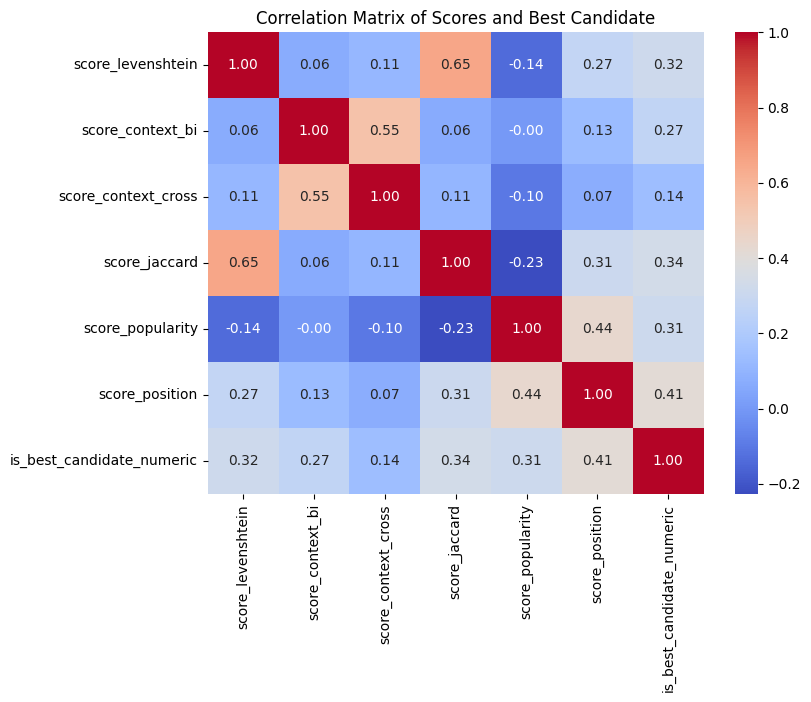

------------------------------
Insights from the correlation matrix:
The correlation values range from -1 to 1:
- A positive correlation indicates that as the score increases, the likelihood of being the best candidate also tends to increase.
- A negative correlation indicates that as the score increases, the likelihood of being the best candidate tends to decrease.
- A correlation close to 0 suggests a weak linear relationship.
------------------------------


/tmp/ipykernel_535058/1553540546.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Is Best Candidate')


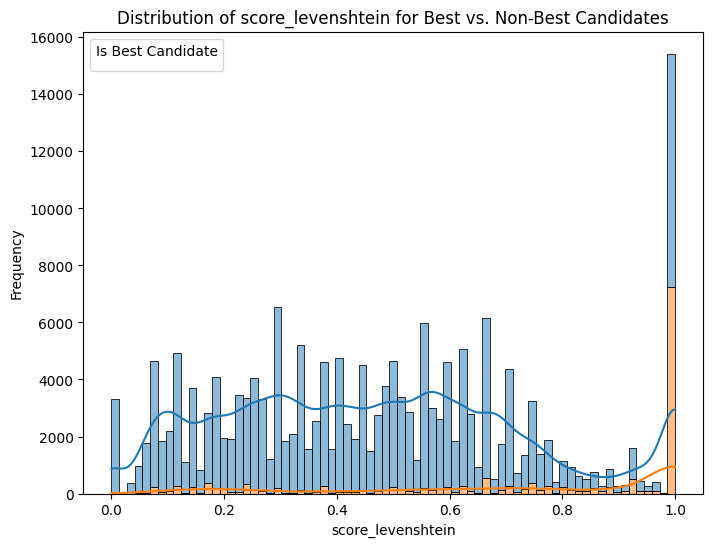

Insights from the distribution of score_levenshtein:
- Observe if the distribution of score_levenshtein for 'True' and 'False' values of 'is_best_candidate' are clearly separated.
- If the distributions are well-separated, it suggests that this metric is a good indicator of whether a candidate is the best.
- Overlapping distributions indicate that the metric alone might not be sufficient for accurate selection.
------------------------------


ValueError: Could not interpret value `score_context` for `x`. An entry with this name does not appear in `data`.

<Figure size 800x600 with 0 Axes>

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_with_best_flag is your DataFrame

def analyze_score_correlation(df):
    """
    Analyzes the correlation between the scores (levenshtein, context, popularity)
    and whether a candidate is the best one ('is_best_candidate').

    Args:
        df (pd.DataFrame): DataFrame with score columns and 'is_best_candidate'.
    """

    # Convert boolean to integer for correlation calculation
    df['is_best_candidate_numeric'] = df['is_best_candidate'].astype(int)

    # Calculate the correlation matrix
    correlation_matrix = df[['score_levenshtein', 'score_context_bi', 'score_context_cross', 'score_jaccard', 'score_popularity','score_position', 'is_best_candidate_numeric']].corr()
    print("Correlation Matrix:")
    print(correlation_matrix)
    print("-" * 30)

    # Visualize the correlation matrix using a heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix of Scores and Best Candidate')
    plt.show()

    print("-" * 30)
    print("Insights from the correlation matrix:")
    print("The correlation values range from -1 to 1:")
    print("- A positive correlation indicates that as the score increases, the likelihood of being the best candidate also tends to increase.")
    print("- A negative correlation indicates that as the score increases, the likelihood of being the best candidate tends to decrease.")
    print("- A correlation close to 0 suggests a weak linear relationship.")
    print("-" * 30)

    # Visualize the distribution of scores for best and non-best candidates
    score_columns = ['score_levenshtein', 'score_context', 'score_popularity']
    for col in score_columns:
        plt.figure(figsize=(8, 6))
        sns.histplot(data=df, x=col, hue='is_best_candidate', kde=True, multiple="stack")
        plt.title(f'Distribution of {col} for Best vs. Non-Best Candidates')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.legend(title='Is Best Candidate')
        plt.show()
        print(f"Insights from the distribution of {col}:")
        print(f"- Observe if the distribution of {col} for 'True' and 'False' values of 'is_best_candidate' are clearly separated.")
        print(f"- If the distributions are well-separated, it suggests that this metric is a good indicator of whether a candidate is the best.")
        print(f"- Overlapping distributions indicate that the metric alone might not be sufficient for accurate selection.")
        print("-" * 30)

# Analyze the correlation
analyze_score_correlation(df_with_best_flag.copy())

### Evaluation with aida test full:

#### Calculate scores for candidates

In [13]:
test_json_file_path = "../DjangoApp/NEL_project/NEL_app/Evaluation/candidate_selection_data/candidates_data_collector_20250418_092239.json"

In [14]:

# Load the JSON data
with open(test_json_file_path, "r", encoding="utf-8") as file:
    test_data = json.load(file)

# Show top-level structure
print("Keys in loaded JSON:")
print(test_data.keys())

# Access configuration
print("\nConfiguration:")
print(test_data["configuration"])

test_golden_annotations = test_data["golden_annotations"]
test_predictions = test_data["predictions"]

Keys in loaded JSON:
dict_keys(['name', 'configuration', 'golden_annotations', 'predictions'])

Configuration:
{'dataset_path': './EvaluationDatasets/aida_test_full.json', 'dataset_total_texts': 230, 'dataset_total_mentions': 4463, 'ned_knowledge_graph': 'dbpedia'}


In [ ]:

# ========== Calculate Scores ==========
test_scored_data = []

for entry in tqdm(test_predictions, desc="Scoring test predictions"):
    context_text = entry["content"]
    for entity in entry["entities"]:
        entity_label = entity["entity_label"]
        start_position = entity["start_position"]
        end_position = entity["end_position"]
        candidates = entity["candidates"]

        # Popularity scores (batch)
        pop_scores = popularity_scorer.score_all(candidates)
        # Position scores (batch)
        pos_scores = position_scorer.score_all(candidates)

        for i, candidate in enumerate(candidates):
            label = candidate["label"]
            comment = candidate.get("comment", "")

            score_lev = levenshtein_scorer.score(entity_label, label)
            score_ctx_bi = context_scorer_bi.score(context_text, comment)
            score_ctx_cross = context_scorer_cross.score(context_text, comment)
            score_jac = jaccard_scorer.score(entity_label, label)
            score_pop = pop_scores[i]
            score_pos = pos_scores[i]

            test_scored_data.append({
                "context_text": context_text,
                "entity_label": entity_label,
                "start_position": start_position,
                "end_position": end_position,
                "candidate_label": label,
                "candidate_uri": candidate["uri"],
                "score_levenshtein": score_lev,
                "score_context_bi": score_ctx_bi,
                "score_context_cross": score_ctx_cross,
                "score_jaccard": score_jac,
                "score_popularity": score_pop,
                "score_position": score_pos
            })

# ========== Convert to DataFrame for Analysis or Model Input ==========
test_df = pd.DataFrame(test_scored_data)

In [ ]:
import pandas as pd
from datetime import datetime

# Assuming your DataFrame is named 'df'
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save to a CSV file with timestamp in the filename
csv_filename = f'test_scored_data_{timestamp}.csv'
test_df.to_csv(csv_filename, index=False)
print(f"DataFrame saved to {csv_filename}")

#### Read scored candidaes from csv

In [15]:
test_df = pd.read_csv("test_scored_data_20250418_093530.csv")

In [16]:
# Normalize score_context_cross (unchanged)
min_cross = test_df['score_context_cross'].min()
max_cross = test_df['score_context_cross'].max()
test_df['score_context_cross'] = (test_df['score_context_cross'] - min_cross) / (max_cross - min_cross)

# Properly invert and normalize score_position to [0, 1]
min_pos = test_df['score_position'].min()  # should be 1
max_pos = test_df['score_position'].max()  # should be 10

test_df['score_position'] = (max_pos - test_df['score_position']) / (max_pos - min_pos)

# Optional: verify
print(test_df[['score_context_cross', 'score_position']].describe())


       score_context_cross  score_position
count         44610.000000    44610.000000
mean              0.402249        0.500022
std               0.159289        0.319146
min               0.000000        0.000000
25%               0.292040        0.222222
50%               0.399219        0.555556
75%               0.512990        0.777778
max               1.000000        1.000000


In [37]:
test_df.describe()

,start_position,end_position,score_levenshtein,score_context_bi,score_context_cross,score_jaccard,score_popularity,score_position
count,44610.000000,44610.000000,44610.000000,44610.000000,44610.000000,44610.000000,44610.000000,44610.000000
mean,730.298700,739.195091,0.460290,0.198159,0.402249,0.334844,0.378351,0.500022
std,695.540818,695.532576,0.272301,0.169520,0.159289,0.291314,0.339316,0.319146
min,0.000000,3.000000,0.000000,-0.170000,0.000000,0.000000,0.000000,0.000000
25%,208.000000,218.000000,0.240000,0.062000,0.292040,0.000000,0.073000,0.222222
50%,523.000000,532.000000,0.440000,0.180000,0.399219,0.333000,0.289000,0.555556
75%,1059.000000,1065.000000,0.640000,0.310000,0.512990,0.500000,0.638000,0.777778
max,4015.000000,4045.000000,1.000000,0.811000,1.000000,1.000000,1.000000,1.000000


In [17]:

# ========== Prepare Data for the Neural Network with Grouping ==========

def create_best_candidate_flag_grouped(predictions_df, golden_annotations):
    best_candidate_uris = {}
    for gold_entry in golden_annotations:
        for entity in gold_entry['entities']:
            key = (gold_entry['content'], entity['entity_label'], entity['start_position'], entity['end_position'])
            best_candidate_uris[key] = entity['best_candidate_uri']

    predictions_df['is_best_candidate'] = False
    for index, row in predictions_df.iterrows():
        key = (row['context_text'], row['entity_label'], row['start_position'], row['end_position'])
        if key in best_candidate_uris and row['candidate_uri'] == best_candidate_uris[key]:
            predictions_df.loc[index, 'is_best_candidate'] = True
    return predictions_df

test_df_with_best_flag = create_best_candidate_flag_grouped(test_df.copy(), test_golden_annotations)


In [18]:
test_df_with_best_flag.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44610 entries, 0 to 44609
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   context_text         44610 non-null  object 
 1   entity_label         44610 non-null  object 
 2   start_position       44610 non-null  int64  
 3   end_position         44610 non-null  int64  
 4   candidate_label      44604 non-null  object 
 5   candidate_uri        44610 non-null  object 
 6   score_levenshtein    44610 non-null  float64
 7   score_context_bi     44610 non-null  float64
 8   score_context_cross  44610 non-null  float64
 9   score_jaccard        44610 non-null  float64
 10  score_popularity     44610 non-null  float64
 11  score_position       44610 non-null  float64
 12  is_best_candidate    44610 non-null  bool   
dtypes: bool(1), float64(6), int64(2), object(4)
memory usage: 4.1+ MB


### Random Forest Classifier

#### Trainig

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Assuming df_with_best_flag is your DataFrame as described

# === 1. Build a grouped dataset for Random Forest ===
def build_grouped_dataframe_rf(df, max_candidates=10):
    grouped_features = []
    targets = []

    # group by unique entity occurrence
    for key, group in df.groupby(['context_text','entity_label','start_position','end_position']):
        candidates = group[['score_levenshtein','score_context_bi','score_context_cross',
                            'score_jaccard','score_popularity','score_position']].values
        # pad up to max_candidates
        if len(candidates) < max_candidates:
            pad = np.zeros((max_candidates - len(candidates), candidates.shape[1]))
            candidates = np.vstack([candidates, pad])
        elif len(candidates) > max_candidates:
            candidates = candidates[:max_candidates]

        # find the index of the best
        best_idx = group['is_best_candidate'].values.argmax()  # first True
        grouped_features.append(candidates.flatten().astype(np.float32)) # Flatten for RF
        targets.append(best_idx)

    X = np.stack(grouped_features)      # (N_entities, 10 * 6)
    y = np.array(targets)                # (N_entities,)
    return X, y

X_rf, y_rf = build_grouped_dataframe_rf(df_with_best_flag, max_candidates=10)
print("X_rf shape:", X_rf.shape, "y_rf shape:", y_rf.shape)

# === 2. Train/Val Split for Random Forest ===
X_train_rf, X_val_rf, y_train_rf, y_val_rf = train_test_split(X_rf, y_rf, test_size=0.2)

# === 3. Define the Random Forest Pipeline ===
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),      # Feature scaling is often beneficial for RF
    ('classifier', RandomForestClassifier()) # You can add hyperparameters here
])

# === 4. Training the Random Forest Model ===
rf_pipeline.fit(X_train_rf, y_train_rf)

# === 5. Evaluation on Validation Set ===
y_pred_val_rf = rf_pipeline.predict(X_val_rf)
val_accuracy_rf = accuracy_score(y_val_rf, y_pred_val_rf)
print(f"\nValidation Accuracy (Random Forest): {val_accuracy_rf:.4f}")
print("\nValidation Classification Report (Random Forest):\n", classification_report(y_val_rf, y_pred_val_rf))

# === 6. Feature Importance Assessment ===
feature_names_rf = [
    f"cand_{i}_score_levenshtein" for i in range(10)
] + [
    f"cand_{i}_score_context_bi" for i in range(10)
] + [
    f"cand_{i}_score_context_cross" for i in range(10)
] + [
    f"cand_{i}_score_jaccard" for i in range(10)
] + [
    f"cand_{i}_score_popularity" for i in range(10)
] + [
    f"cand_{i}_score_position" for i in range(10)
]

if hasattr(rf_pipeline.named_steps['classifier'], 'feature_importances_'):
    importances = rf_pipeline.named_steps['classifier'].feature_importances_
    feature_importance_dict = dict(zip(feature_names_rf, importances))
    sorted_feature_importance = sorted(feature_importance_dict.items(), key=lambda item: item[1], reverse=True)

    print("\nFeature Importance (Random Forest):")
    for feature, importance in sorted_feature_importance:
        print(f"{feature}: {importance:.4f}")

    # Identify potentially less important metrics (across all candidates)
    importance_per_metric = {}
    for i in range(10):
        importance_per_metric['levenshtein'] = importance_per_metric.get('levenshtein', 0) + feature_importance_dict[f"cand_{i}_score_levenshtein"]
        importance_per_metric['context_bi'] = importance_per_metric.get('context_bi', 0) + feature_importance_dict[f"cand_{i}_score_context_bi"]
        importance_per_metric['context_cross'] = importance_per_metric.get('context_cross', 0) + feature_importance_dict[f"cand_{i}_score_context_cross"]
        importance_per_metric['jaccard'] = importance_per_metric.get('jaccard', 0) + feature_importance_dict[f"cand_{i}_score_jaccard"]
        importance_per_metric['popularity'] = importance_per_metric.get('popularity', 0) + feature_importance_dict[f"cand_{i}_score_popularity"]
        importance_per_metric['position'] = importance_per_metric.get('position', 0) + feature_importance_dict[f"cand_{i}_score_position"]

    sorted_metric_importance = sorted(importance_per_metric.items(), key=lambda item: item[1], reverse=True)
    print("\nTotal Importance per Metric:")
    for metric, total_importance in sorted_metric_importance:
        print(f"{metric}: {total_importance:.4f}")

    # Suggest dropping less important metrics (you'll need to define a threshold)
    threshold = 0.01 # Example threshold - adjust as needed
    less_important_metrics = [metric for metric, importance in sorted_metric_importance if importance < threshold]
    if less_important_metrics:
        print(f"\nPotentially less important metrics (below threshold {threshold}): {less_important_metrics}")
        print("Consider removing these metrics from your feature set and retraining.")
    else:
        print("\nAll metrics appear to have some level of importance based on the current model.")
else:
    print("\nFeature importance is not available for this Random Forest model.")

X_rf shape: (18394, 60) y_rf shape: (18394,)

Validation Accuracy (Random Forest): 0.9448

Validation Classification Report (Random Forest):
               precision    recall  f1-score   support

           0       0.94      0.99      0.97      2860
           1       0.94      0.80      0.86       309
           2       0.97      0.81      0.88       208
           3       0.98      0.75      0.85        77
           4       0.96      0.75      0.85        73
           5       0.91      0.74      0.82        43
           6       1.00      0.73      0.85        49
           7       1.00      0.69      0.82        13
           8       1.00      0.68      0.81        28
           9       0.86      0.95      0.90        19

    accuracy                           0.94      3679
   macro avg       0.96      0.79      0.86      3679
weighted avg       0.95      0.94      0.94      3679


Feature Importance (Random Forest):
cand_1_score_levenshtein: 0.0582
cand_7_score_levenshtein: 0.0

##### evaluation

In [22]:


# === 7. Evaluation on Test Set (similar to validation) ===
# Assuming you have X_test_rf and y_test_rf prepared in the same way as X_train_rf and y_train_rf
X_test_rf, y_test_rf = build_grouped_dataframe_rf(test_df_with_best_flag, max_candidates=10)
y_pred_test_rf = rf_pipeline.predict(X_test_rf)
test_accuracy_rf = accuracy_score(y_test_rf, y_pred_test_rf)
print(f"\nTest Accuracy (Random Forest): {test_accuracy_rf:.4f}")
print("\nTest Classification Report (Random Forest):\n", classification_report(y_test_rf, y_pred_test_rf))


Test Accuracy (Random Forest): 0.8324

Test Classification Report (Random Forest):
               precision    recall  f1-score   support

           0       0.83      0.99      0.90      3359
           1       0.84      0.48      0.61       416
           2       0.87      0.35      0.50       256
           3       0.90      0.33      0.48       143
           4       0.79      0.18      0.29        84
           5       0.64      0.18      0.29        38
           6       0.90      0.16      0.26        58
           7       1.00      0.19      0.32        47
           8       1.00      0.31      0.48        32
           9       0.80      0.14      0.24        29

    accuracy                           0.83      4462
   macro avg       0.86      0.33      0.44      4462
weighted avg       0.84      0.83      0.80      4462



todo - add evalaution with real test dataset

### Model with 7 featuers

In [1]:
import json
import pandas as pd
from datetime import datetime
from tqdm import tqdm
from sentence_transformers import SentenceTransformer, util, CrossEncoder
from fuzzywuzzy import fuzz
import numpy as np
from nltk.tokenize import RegexpTokenizer
import torch
from concurrent.futures import ThreadPoolExecutor, as_completed

2025-04-23 09:05:16.439081: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-23 09:05:16.446004: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745391916.454331  590567 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745391916.456859  590567 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745391916.463592  590567 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

#### New scorer - types embedding similarity

In [24]:
# 1) New Scorer ----------------------------------------------------------------
class TypesEmbeddingScorer:
    """
    Class to calculate scores for candidates based on NER entity type probabilities
    and candidate ontology types using embeddings of their descriptions.
    """
    def __init__(self, model_name="all-MiniLM-L6-v2", round_to_decimal_places=3, device=None):
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.embeddings_model = SentenceTransformer(model_name).to(self.device)
        self.round_to_decimal_places = round_to_decimal_places
        self.ner_type_definitions = {
            "PERSON": "Proper names of people including first names, last names, individual or family names, fictional names and unique nicknames.",
            "NORP": "Adjectival forms of GPE and non-GPE place names (such as American), named religions, heritage, and political affiliation.",
            "FAC": "Names of man-made structures, including the buildings, airports, stations, infrastructures (bridges and streets), monuments, oil fields, golf courses, hospitals, zoos, shopping centers, etc.",
            "ORG": "Names of companies, government agencies, political parties, educational institutions, sport teams, hospitals, museums, libraries etc.",
            "GPE": "Names of geographical administrative entities including countries, villages, cities, states, provinces, prefectures, and other forms of municipalities",
            "LOC": "Names of locations other than GPEs including celestial bodies, stars, continents, mountains, oceans, coasts, rivers, lakes, borders, etc.",
            "PRODUCT": "Name of any product including non-commercial vehicles (automobiles, rockets, aircraft, ships).",
            "EVENT": "Named events and phenomena including natural disasters, hurricanes, revolutions, battles, wars, demonstrations, concerts, sports events, etc.",
            "WORK_OF_ART": "Titles of books, songs, films, plays and other creations such as awards, stock price indexes, and social security systems including health insurance systems or pension plans.",
            "LAW": "Named legal documents including laws, treaties, sections, and chapters.",
            "LANGUAGE": "Any named language including programming languages.",
            "O": "Unknown" # - Removed "O" from the definitions
        }
        self.ner_embeddings_cache = {
            ner_type: self.get_embedding(definition)
            for ner_type, definition in self.ner_type_definitions.items()
        }

    def get_embedding(self, sentence):
        """Generate word embedding using embeddings model."""
        embedding = self.embeddings_model.encode(sentence, convert_to_tensor=True).to(self.device)
        return embedding

    def score_types_embedding(self, entity_probabilities: list, ontology_types: list) -> float:
        """
        Calculates a raw score for a candidate based on NER entity type probabilities
        and candidate ontology types by comparing embeddings of their descriptions.
        Skips "O" NER types during similarity calculation.
        """
        if not ontology_types or not entity_probabilities:
            return 0.0

        valid_ner_probabilities = [(cls, prob) for cls, prob in entity_probabilities if cls != "O"]
        if not valid_ner_probabilities:
            return 0.0

        ner_classes = [item[0] for item in valid_ner_probabilities]
        ner_probabilities = np.array([float(item[1]) for item in valid_ner_probabilities])

        kg_embeddings = {kg_type: self.get_embedding(kg_type) for kg_type in ontology_types}

        similarity_matrix = np.zeros((len(ner_classes), len(ontology_types)))

        for i, ner_cls in enumerate(ner_classes):
            ner_embedding = self.ner_embeddings_cache.get(ner_cls)
            if ner_embedding is not None:
                for j, kg_type in enumerate(ontology_types):
                    kg_embedding = kg_embeddings.get(kg_type)
                    if kg_embedding is not None:
                        similarity_matrix[i, j] = util.pytorch_cos_sim(ner_embedding.unsqueeze(0), kg_embedding.unsqueeze(0)).item()

        candidate_score = 0.0
        if ontology_types and ner_probabilities.size > 0 and similarity_matrix.shape[0] > 0 and similarity_matrix.shape[1] > 0:
            weighted_similarities = np.array([
                np.sum(ner_probabilities * similarity_matrix[:, j]) for j in range(len(ontology_types))
            ])
            candidate_score = np.mean(weighted_similarities) if weighted_similarities.size > 0 else 0.0

        return candidate_score

    def normalize_score(self, raw_scores: list) -> list:
        """
        Normalizes a list of raw embedding-based type scores to the range [0, 1].

        Args:
            raw_scores (list): A list of raw type embedding scores.

        Returns:
            list: A list of normalized type embedding scores.
        """
        if not raw_scores:
            return []

        min_score = min(raw_scores)
        max_score = max(raw_scores)

        if max_score == min_score:
            return [round(1.0, self.round_to_decimal_places)] * len(raw_scores)
        else:
            normalized_scores = [(score - min_score) / (max_score - min_score)
                                 for score in raw_scores]
            return [round(score, self.round_to_decimal_places) for score in normalized_scores]

# ========== Initialize Scorers ==========
types_embedding_scorer = TypesEmbeddingScorer()

#### Score candidates

In [25]:
# aida dataset train data
json_file_paths = [
    # "../DjangoApp/NEL_project/NEL_app/Evaluation/candidate_selection_data/candidates_data_collector_20250422_155658.json", # conll
    "../DjangoApp/NEL_project/NEL_app/Evaluation/candidate_selection_data/candidates_data_collector_20250422_160033.json", # ontonotes
    # "../DjangoApp/NEL_project/NEL_app/Evaluation/candidate_selection_data/candidates_data_collector_20250422_160142.json", # fewnerd
]

# Load the JSON data (and merge these three files)
all_data = []
for json_file_path in json_file_paths:
    with open(json_file_path, "r", encoding="utf-8") as file:
        all_data.append(json.load(file))


named_entities_annotations = all_data[0].get("named_entities_annotations", [])
predictions_data = all_data[0].get("predictions", [])


In [26]:
# Show top-level structure
data = all_data[0]
print("Keys in loaded JSON:")
print(data.keys())

# Access configuration
print("\nConfiguration:")
print(data["configuration"])

# Access one golden annotation entry
print("\nSample named_entities_annotations:")
print(data["named_entities_annotations"][0])

# Access one prediction entry and its candidates
print("\nSample Prediction with Candidates:")
print(data["predictions"][0])


Keys in loaded JSON:
dict_keys(['name', 'configuration', 'named_entities_annotations', 'predictions'])

Configuration:
{'dataset_path': './EvaluationDatasets/aida_train_converted.json', 'dataset_total_texts': 940, 'dataset_total_mentions': 18395, 'ned_knowledge_graph': 'dbpedia', 'use_golden_annotations': False, 'ner_model_name': 'tomaarsen/span-marker-roberta-large-ontonotes5', 'ner_accuracy': 0.7509078681909885}

Sample named_entities_annotations:
{'content': 'EU rejects German call to boycott British lamb . Peter Blackburn BRUSSELS 1996-08-22 The European Commission said on Thursday it disagreed with German advice to consumers to shun British lamb until scientists determine whether mad cow disease can be transmitted to sheep . Germany \'s representative to the European Union \'s veterinary committee Werner Zwingmann said on Wednesday consumers should buy sheepmeat from countries other than Britain until the scientific advice was clearer . " We do n\'t support any such recommendation

In [62]:
def process_entry(ner_annotation, prediction_entry):
    scored_candidates = []
    context_text = ner_annotation.get("content")
    ner_entities = ner_annotation.get("entities", [])
    prediction_entities = prediction_entry.get("entities", [])

    # Create a mapping between (start_position, end_position, entity_label) for NER and Predictions
    ner_entity_map = {
        (ent.get("start_position"), ent.get("end_position"), ent.get("entity_label")): ent
        for ent in ner_entities
    }

    for predicted_entity in prediction_entities:
        start = predicted_entity.get("start_position")
        end = predicted_entity.get("end_position")
        pred_label = predicted_entity.get("entity_label")
        ner_entity = ner_entity_map.get((start, end, pred_label))

        if ner_entity:
            entity_label = predicted_entity.get("entity_label")
            candidates = predicted_entity.get("candidates", [])
            entity_probabilities_raw = ner_entity.get("probabilities", [])
            entity_probabilities = []
            if entity_probabilities_raw:
                for prob in entity_probabilities_raw:
                    if len(prob) == 2:
                        entity_probabilities.append((prob[0], float(prob[1])))

            pop_scores = popularity_scorer.score_all(candidates)
            pos_scores = position_scorer.score_all(candidates)
            all_cross_scores_local = []
            all_raw_pos_scores_local = []
            all_raw_types_embedding_scores_local = []
            scored_candidates_local = []

            for i, candidate in enumerate(candidates):
                label = candidate.get("label")
                comment = candidate.get("comment", "")
                ontology_types = candidate.get("ontology_types", [])

                score_lev = levenshtein_scorer.score(entity_label, label)
                score_ctx_bi = context_scorer_bi.score(context_text, comment)
                score_ctx_cross_raw = context_scorer_cross.score(context_text, comment)
                score_jac = jaccard_scorer.score(entity_label, label)
                score_pop = pop_scores[i]
                score_pos_raw = i + 1
                score_types_embedding_raw = types_embedding_scorer.score_types_embedding(entity_probabilities, ontology_types)

                scored_candidates_local.append({
                    "context_text": context_text,
                    "entity_label": entity_label,
                    "start_position": start,
                    "end_position": end,
                    "candidate_label": label,
                    "candidate_uri": candidate.get("uri"),
                    "score_levenshtein": score_lev,
                    "score_context_bi": score_ctx_bi,
                    "score_context_cross_raw": score_ctx_cross_raw,
                    "score_jaccard": score_jac,
                    "score_popularity": score_pop,
                    "score_position_raw": score_pos_raw,
                    "score_types_embedding_raw": score_types_embedding_raw
                })
                all_cross_scores_local.append(score_ctx_cross_raw)
                all_raw_pos_scores_local.append(score_pos_raw)
                all_raw_types_embedding_scores_local.append(score_types_embedding_raw)

            normalized_cross_scores = context_scorer_cross.normalize_score(all_cross_scores_local)
            normalized_pos_scores = position_scorer.normalize_score(all_raw_pos_scores_local)
            normalized_types_embedding_scores = types_embedding_scorer.normalize_score(all_raw_types_embedding_scores_local)

            for i in range(len(scored_candidates_local)):
                scored_candidates_local[i]["score_context_cross"] = normalized_cross_scores[i]
                scored_candidates_local[i]["score_position"] = normalized_pos_scores[i]
                scored_candidates_local[i]["score_types_embedding"] = normalized_types_embedding_scores[i]

            scored_candidates.extend(scored_candidates_local)
    return scored_candidates

In [ ]:
# Parallel processing for the first document's entities
num_documents_to_process = len(named_entities_annotations)
scored_data = []

if len(named_entities_annotations) == len(predictions_data):
    with ThreadPoolExecutor(max_workers=4) as executor: # Adjust max_workers as needed
        futures = []
        for i in range(min(num_documents_to_process, len(named_entities_annotations))):
            ner_annotation = named_entities_annotations[i]
            prediction_entry = predictions_data[i]
            future = executor.submit(process_entry, ner_annotation, prediction_entry)
            futures.append(future)

        for future in tqdm(as_completed(futures), total=num_documents_to_process, desc="Processing documents"):
            scored_data.extend(future.result())

else:
    print("Error: The number of named entity annotations and predictions does not match.")

# ========== Convert to DataFrame for Analysis or Model Input ==========
df = pd.DataFrame(scored_data)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
csv_filename = f'scored_data_first_document_entities_normalized_{timestamp}.csv'
df.to_csv(csv_filename, index=False)
print(f"DataFrame saved to {csv_filename}")

Processing documents: 100%|██████████████████████████████████████████████████████████████████| 940/940 [27:14<00:00,  1.74s/it]


DataFrame saved to scored_data_first_document_entities_normalized_20250422_222248.csv


#### Read scored candidates from csv 

In [27]:
df = pd.read_csv("scored_data_first_document_entities_normalized_20250422_222248.csv")

In [28]:
df.describe()

,start_position,end_position,score_levenshtein,score_context_bi,score_context_cross_raw,score_jaccard,score_popularity,score_position_raw,score_types_embedding_raw,score_context_cross,score_position,score_types_embedding
count,111596.000000,111596.000000,111596.000000,111596.000000,111596.000000,111596.000000,111596.000000,111596.000000,111596.000000,111596.000000,111596.000000,111596.000000
mean,397.458690,406.259956,0.462639,0.205012,-4.533038,0.331520,0.378618,5.498862,0.095826,0.477336,0.500000,0.473934
std,307.597795,307.710005,0.274474,0.177460,2.677511,0.293581,0.338898,2.872363,0.085584,0.330116,0.319284,0.397048
min,0.000000,3.000000,0.000000,-0.208000,-11.349730,0.000000,0.000000,1.000000,-0.069199,0.000000,0.000000,0.000000
25%,128.000000,137.000000,0.240000,0.056000,-6.501428,0.000000,0.075000,3.000000,0.000000,0.192000,0.222000,0.000000
50%,339.000000,348.000000,0.445000,0.188000,-4.555939,0.333000,0.286000,5.000000,0.093076,0.463000,0.500000,0.511000
75%,612.000000,622.000000,0.640000,0.334000,-2.620049,0.500000,0.635000,8.000000,0.154624,0.751000,0.778000,0.889000
max,1391.000000,1399.000000,1.000000,0.843000,6.041580,1.000000,1.000000,10.000000,0.428192,1.000000,1.000000,1.000000


In [29]:
df

,context_text,entity_label,start_position,end_position,candidate_label,candidate_uri,score_levenshtein,score_context_bi,score_context_cross_raw,score_jaccard,score_popularity,score_position_raw,score_types_embedding_raw,score_context_cross,score_position,score_types_embedding
0,China says time right for Taiwan talks . BEIJI...,China,0,5,China,http://dbpedia.org/resource/China,1.00,0.294,-2.739792,1.000,1.000,1,0.164444,0.666,1.000,1.000
1,China says time right for Taiwan talks . BEIJI...,China,0,5,Taiwan,http://dbpedia.org/resource/Taiwan,0.36,0.425,-0.808266,0.000,0.732,2,0.164444,1.000,0.889,1.000
2,China says time right for Taiwan talks . BEIJI...,China,0,5,China national football team,http://dbpedia.org/resource/China_national_foo...,0.30,0.281,-4.898012,0.250,0.259,3,0.092457,0.293,0.778,0.562
3,China says time right for Taiwan talks . BEIJI...,China,0,5,South China AA,http://dbpedia.org/resource/South_China_AA,0.53,0.154,-6.594537,0.333,0.140,4,0.092457,0.000,0.667,0.562
4,China says time right for Taiwan talks . BEIJI...,China,0,5,District (China),http://dbpedia.org/resource/District_(China),0.48,0.149,-5.346450,0.500,0.136,5,0.000000,0.216,0.556,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111591,GOLF - BRITISH MASTERS THIRD ROUND SCORES . NO...,Ireland,845,852,Dublin,http://dbpedia.org/resource/Dublin,0.31,-0.019,-10.498098,0.000,0.407,6,0.155025,0.064,0.444,0.954
111592,GOLF - BRITISH MASTERS THIRD ROUND SCORES . NO...,Ireland,845,852,Northern Ireland national football team,http://dbpedia.org/resource/Northern_Ireland_n...,0.30,-0.020,-9.775723,0.200,0.060,7,0.091277,0.395,0.333,0.562
111593,GOLF - BRITISH MASTERS THIRD ROUND SCORES . NO...,Ireland,845,852,Republic of Ireland national football team,http://dbpedia.org/resource/Republic_of_Irelan...,0.29,-0.033,-8.456881,0.167,0.054,8,0.091277,1.000,0.222,0.562
111594,GOLF - BRITISH MASTERS THIRD ROUND SCORES . NO...,Ireland,845,852,Republic of Ireland national under-21 football...,http://dbpedia.org/resource/Republic_of_Irelan...,0.24,0.019,-8.467862,0.125,0.000,9,0.091277,0.995,0.111,0.562


In [30]:
df_with_best_flag = create_best_candidate_flag_grouped(df.copy(), golden_annotations)


In [31]:
df_with_best_flag.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111596 entries, 0 to 111595
Data columns (total 17 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   context_text               111596 non-null  object 
 1   entity_label               111596 non-null  object 
 2   start_position             111596 non-null  int64  
 3   end_position               111596 non-null  int64  
 4   candidate_label            111585 non-null  object 
 5   candidate_uri              111596 non-null  object 
 6   score_levenshtein          111596 non-null  float64
 7   score_context_bi           111596 non-null  float64
 8   score_context_cross_raw    111596 non-null  float64
 9   score_jaccard              111596 non-null  float64
 10  score_popularity           111596 non-null  float64
 11  score_position_raw         111596 non-null  int64  
 12  score_types_embedding_raw  111596 non-null  float64
 13  score_context_cross        11

#### Train 

In [68]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Assuming df_with_best_flag is your DataFrame with the 'is_best_candidate' column
# created using the create_best_candidate_flag_grouped function

# === 1. Build a grouped dataset for Random Forest ===
def build_grouped_dataframe_rf(df, max_candidates=10):
    grouped_features = []
    targets = []

    # group by unique entity occurrence
    for key, group in df.groupby(['context_text','entity_label','start_position','end_position']):
        candidates = group[[
            'score_levenshtein',
            'score_context_bi',
            'score_context_cross',
            'score_jaccard',
            'score_popularity',
            'score_position',
            'score_types_embedding'
        ]].values
        # pad up to max_candidates
        if len(candidates) < max_candidates:
            pad = np.zeros((max_candidates - len(candidates), candidates.shape[1]))
            candidates = np.vstack([candidates, pad])
        elif len(candidates) > max_candidates:
            candidates = candidates[:max_candidates]

        # find the index of the best
        best_idx = group['is_best_candidate'].values.argmax()  # first True
        grouped_features.append(candidates.flatten().astype(np.float32)) # Flatten for RF
        targets.append(best_idx)

    X = np.stack(grouped_features)      # (N_entities, 10 * 7)
    y = np.array(targets)                # (N_entities,)
    return X, y

X_rf, y_rf = build_grouped_dataframe_rf(df_with_best_flag, max_candidates=10)
print("X_rf shape:", X_rf.shape, "y_rf shape:", y_rf.shape)

# === 2. Train/Val Split for Random Forest ===
X_train_rf, X_val_rf, y_train_rf, y_val_rf = train_test_split(X_rf, y_rf, test_size=0.2) # Added random_state for reproducibility

# === 3. Define the Random Forest Pipeline ===
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),      # Feature scaling is often beneficial for RF
    ('classifier', RandomForestClassifier()) # You can add hyperparameters here
])

# === 4. Training the Random Forest Model ===
rf_pipeline.fit(X_train_rf, y_train_rf)

# === 5. Evaluation on Validation Set ===
y_pred_val_rf = rf_pipeline.predict(X_val_rf)
val_accuracy_rf = accuracy_score(y_val_rf, y_pred_val_rf)
print(f"\nValidation Accuracy (Random Forest): {val_accuracy_rf:.4f}")
print("\nValidation Classification Report (Random Forest):\n", classification_report(y_val_rf, y_pred_val_rf, zero_division=0))

# === 6. Feature Importance Assessment ===
feature_names_rf = [
    f"cand_{i}_score_levenshtein" for i in range(10)
] + [
    f"cand_{i}_score_context_bi" for i in range(10)
] + [
    f"cand_{i}_score_context_cross" for i in range(10)
] + [
    f"cand_{i}_score_jaccard" for i in range(10)
] + [
    f"cand_{i}_score_popularity" for i in range(10)
] + [
    f"cand_{i}_score_position" for i in range(10)
] + [
    f"cand_{i}_score_types_embedding" for i in range(10) # Added types embedding
]

if hasattr(rf_pipeline.named_steps['classifier'], 'feature_importances_'):
    importances = rf_pipeline.named_steps['classifier'].feature_importances_
    feature_importance_dict = dict(zip(feature_names_rf, importances))
    sorted_feature_importance = sorted(feature_importance_dict.items(), key=lambda item: item[1], reverse=True)

    print("\nFeature Importance (Random Forest):")
    for feature, importance in sorted_feature_importance:
        print(f"{feature}: {importance:.4f}")

    # Identify potentially less important metrics (across all candidates)
    importance_per_metric = {}
    metrics = [
        'levenshtein', 'context_bi', 'context_cross', 'jaccard', 'popularity', 'position', 'types_embedding'
    ]
    for metric in metrics:
        total_importance = 0
        for i in range(10):
            total_importance += feature_importance_dict.get(f"cand_{i}_score_{metric}", 0)
        importance_per_metric[metric] = total_importance

    sorted_metric_importance = sorted(importance_per_metric.items(), key=lambda item: item[1], reverse=True)
    print("\nTotal Importance per Metric:")
    for metric, total_importance in sorted_metric_importance:
        print(f"{metric}: {total_importance:.4f}")

    # Suggest dropping less important metrics (you'll need to define a threshold)
    threshold = 0.01 # Example threshold - adjust as needed
    less_important_metrics = [metric for metric, importance in sorted_metric_importance if importance < threshold]
    if less_important_metrics:
        print(f"\nPotentially less important metrics (below threshold {threshold}): {less_important_metrics}")
        print("Consider removing these metrics from your feature set and retraining.")
    else:
        print("\nAll metrics appear to have some level of importance based on the current model.")
else:
    print("\nFeature importance is not available for this Random Forest model.")

    # === 7. Evaluation on Test Set (similar to validation) ===

# First, re-split data: 80% train_val, 20% test
X_temp_rf, X_test_rf, y_temp_rf, y_test_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

# Then split train_val into train and val (e.g., 80% train, 20% val of 80%)
X_train_rf, X_val_rf, y_train_rf, y_val_rf = train_test_split(X_temp_rf, y_temp_rf, test_size=0.25, random_state=42)
# This results in: 60% train, 20% val, 20% test

# Re-train the model on training split (optional if you're using a single training phase)
rf_pipeline.fit(X_train_rf, y_train_rf)

# Predict on test set
y_pred_test_rf = rf_pipeline.predict(X_test_rf)

# Evaluate test accuracy and classification report
test_accuracy_rf = accuracy_score(y_test_rf, y_pred_test_rf)
print(f"\nTest Accuracy (Random Forest): {test_accuracy_rf:.4f}")
print("\nTest Classification Report (Random Forest):\n", classification_report(y_test_rf, y_pred_test_rf, zero_division=0))


X_rf shape: (11138, 70) y_rf shape: (11138,)

Validation Accuracy (Random Forest): 0.9439

Validation Classification Report (Random Forest):
               precision    recall  f1-score   support

           0       0.94      0.99      0.97      1726
           1       0.94      0.71      0.81       213
           2       0.99      0.78      0.87       113
           3       0.97      0.84      0.90        43
           4       1.00      0.85      0.92        39
           5       1.00      0.87      0.93        30
           6       1.00      0.83      0.91        24
           7       1.00      0.60      0.75        10
           8       0.93      0.82      0.88        17
           9       0.86      0.92      0.89        13

    accuracy                           0.94      2228
   macro avg       0.96      0.82      0.88      2228
weighted avg       0.94      0.94      0.94      2228


Feature Importance (Random Forest):
cand_2_score_levenshtein: 0.0454
cand_1_score_levenshtein: 0.0

#### Evaluation with test dataset

##### Score candidates

In [63]:
import json
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

# Assuming you have your trained rf_pipeline object
# Also assuming you have initialized popularity_scorer, position_scorer,
# levenshtein_scorer, context_scorer_bi, context_scorer_cross,
# and types_embedding_scorer

# 1. Load the Evaluation Data (similar structure to training data)
evaluation_file_paths = [
    "../DjangoApp/NEL_project/NEL_app/Evaluation/candidate_selection_data/candidates_data_collector_20250422_162357.json", # test aida with NER ontonotes
    # Add more evaluation file paths if needed
]


# Load the JSON data (and merge these three files)
all_data = []
for json_file_path in evaluation_file_paths:
    with open(json_file_path, "r", encoding="utf-8") as file:
        all_data.append(json.load(file))


named_entities_annotations = all_data[0].get("named_entities_annotations", [])
predictions_data = all_data[0].get("predictions", [])



# Parallel processing for the first document's entities
num_documents_to_process = len(named_entities_annotations)
scored_data = []

if len(named_entities_annotations) == len(predictions_data):
    with ThreadPoolExecutor(max_workers=4) as executor: # Adjust max_workers as needed
        futures = []
        for i in range(min(num_documents_to_process, len(named_entities_annotations))):
            ner_annotation = named_entities_annotations[i]
            prediction_entry = predictions_data[i]
            future = executor.submit(process_entry, ner_annotation, prediction_entry)
            futures.append(future)

        for future in tqdm(as_completed(futures), total=num_documents_to_process, desc="Processing documents"):
            scored_data.extend(future.result())

else:
    print("Error: The number of named entity annotations and predictions does not match.")

# ========== Convert to DataFrame for Analysis or Model Input ==========
evaluation_df = pd.DataFrame(scored_data)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
csv_filename = f'scored_data_first_document_entities_normalized_{timestamp}.csv'
evaluation_df.to_csv(csv_filename, index=False)
print(f"DataFrame saved to {csv_filename}")


Processing documents: 100%|██████████████████████████████████████████████████████████████████| 230/230 [06:46<00:00,  1.77s/it]


DataFrame saved to scored_data_first_document_entities_normalized_20250422_232828.csv


In [64]:
import pandas as pd
from datetime import datetime

# Assuming your DataFrame is named 'df'
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save to a CSV file with timestamp in the filename
csv_filename = f'test_scored_data_{timestamp}.csv'
evaluation_df.to_csv(csv_filename, index=False)
print(f"DataFrame saved to {csv_filename}")

DataFrame saved to test_scored_data_20250422_232829.csv


##### Read scored candidates from csv

In [65]:
evaluation_df = pd.read_csv(csv_filename)
evaluation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27381 entries, 0 to 27380
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   context_text               27381 non-null  object 
 1   entity_label               27381 non-null  object 
 2   start_position             27381 non-null  int64  
 3   end_position               27381 non-null  int64  
 4   candidate_label            27377 non-null  object 
 5   candidate_uri              27381 non-null  object 
 6   score_levenshtein          27381 non-null  float64
 7   score_context_bi           27381 non-null  float64
 8   score_context_cross_raw    27381 non-null  float64
 9   score_jaccard              27381 non-null  float64
 10  score_popularity           27381 non-null  float64
 11  score_position_raw         27381 non-null  int64  
 12  score_types_embedding_raw  27381 non-null  float64
 13  score_context_cross        27381 non-null  flo

In [66]:
evaluation_df.describe()

,start_position,end_position,score_levenshtein,score_context_bi,score_context_cross_raw,score_jaccard,score_popularity,score_position_raw,score_types_embedding_raw,score_context_cross,score_position,score_types_embedding
count,27381.000000,27381.000000,27381.000000,27381.000000,27381.000000,27381.000000,27381.000000,27381.000000,27381.000000,27381.000000,27381.000000,27381.000000
mean,387.356853,396.193967,0.456702,0.206671,-4.950597,0.334608,0.377766,5.499836,0.103900,0.469175,0.500018,0.486978
std,301.464295,301.532923,0.273542,0.172528,2.559712,0.290729,0.338756,2.872410,0.091694,0.330276,0.319273,0.398555
min,0.000000,3.000000,0.000000,-0.170000,-11.323305,0.000000,0.000000,1.000000,-0.053733,0.000000,0.000000,0.000000
25%,134.000000,142.000000,0.240000,0.067000,-6.723903,0.000000,0.074000,3.000000,0.000000,0.182000,0.222000,0.000000
50%,328.000000,337.000000,0.440000,0.192000,-5.011048,0.333000,0.287000,5.000000,0.098932,0.447000,0.556000,0.544000
75%,590.000000,598.000000,0.640000,0.319000,-3.177863,0.500000,0.638000,8.000000,0.157462,0.744000,0.778000,0.893000
max,1325.000000,1335.000000,1.000000,0.811000,4.131427,1.000000,1.000000,10.000000,0.466345,1.000000,1.000000,1.000000


In [67]:

# 2. Load Golden Annotations for Evaluation
evaluation_golden_annotations_file = "../DjangoApp/NEL_project/NEL_app/Evaluation/candidate_selection_data/candidates_data_collector_20250418_092239.json" # Your updated path
with open(evaluation_golden_annotations_file, "r", encoding="utf-8") as f:
    evaluation_golden_annotations_data = json.load(f)
    evaluation_golden_annotations = evaluation_golden_annotations_data.get("golden_annotations", [])

# 3. Annotate Evaluation DataFrame with is_best_candidate flag
def create_best_candidate_flag_grouped_evaluation(predictions_df, golden_annotations):
    best_candidate_uris = {}
    for gold_entry in golden_annotations:
        if "entities" in gold_entry and isinstance(gold_entry["entities"], list):
            for ent in gold_entry["entities"]:
                if isinstance(ent, dict) and all(key in ent for key in ["entity_label", "start_position", "end_position", "best_candidate_uri"]):
                    key = (
                        gold_entry["content"],
                        ent["entity_label"],
                        ent["start_position"],
                        ent["end_position"],
                    )
                    best_candidate_uris[key] = ent["best_candidate_uri"]
                else:
                    print(f"Warning: Skipping malformed entity in golden annotation: {ent}")
        else:
            print(f"Warning: 'entities' key not found or is not a list in golden annotation entry: {gold_entry}")

    predictions_df["is_best_candidate"] = False
    for idx, row in predictions_df.iterrows():
        key = (
            row["context_text"],
            row["entity_label"],
            row["start_position"],
            row["end_position"],
        )
        if row["candidate_uri"] == best_candidate_uris.get(key):
            predictions_df.at[idx, "is_best_candidate"] = True
    return predictions_df

evaluation_df_with_best_flag = create_best_candidate_flag_grouped_evaluation(
    evaluation_df.copy(), evaluation_golden_annotations
)

# 4. Build Grouped Arrays for Evaluation
def build_grouped_dataframe_rf_evaluation(df, max_candidates=10):
    grouped_features = []
    targets = []

    for key, group in df.groupby(['context_text','entity_label','start_position','end_position']):
        candidates = group[[
            'score_levenshtein',
            'score_context_bi',
            'score_context_cross', 
            'score_jaccard',
            'score_popularity',
            'score_position', 
            'score_types_embedding'
        ]].values
        if len(candidates) < max_candidates:
            pad = np.zeros((max_candidates - len(candidates), candidates.shape[1]))
            candidates = np.vstack([candidates, pad])
        elif len(candidates) > max_candidates:
            candidates = candidates[:max_candidates]

        best_idx = group['is_best_candidate'].values.argmax() if any(group['is_best_candidate']) else 0
        grouped_features.append(candidates.flatten().astype(np.float32))
        targets.append(best_idx)

    X_eval_rf = np.stack(grouped_features)
    y_eval_rf = np.array(targets, dtype=np.int64)
    return X_eval_rf, y_eval_rf

X_eval_rf, y_eval_rf = build_grouped_dataframe_rf_evaluation(
    evaluation_df_with_best_flag, max_candidates=10
)
print("Evaluation X shape:", X_eval_rf.shape, "Evaluation y shape:", y_eval_rf.shape)

# 5. Evaluate the Trained Model
y_pred_eval_rf = rf_pipeline.predict(X_eval_rf)
eval_accuracy_rf = accuracy_score(y_eval_rf, y_pred_eval_rf)
print(f"\nEvaluation Accuracy (Random Forest): {eval_accuracy_rf:.4f}")
print("\nEvaluation Classification Report (Random Forest):\n", classification_report(y_eval_rf, y_pred_eval_rf, zero_division=0))

Evaluation X shape: (2732, 70) Evaluation y shape: (2732,)

Evaluation Accuracy (Random Forest): 0.8316

Evaluation Classification Report (Random Forest):
               precision    recall  f1-score   support

           0       0.83      0.99      0.90      2074
           1       0.86      0.46      0.60       232
           2       0.89      0.29      0.44       146
           3       0.80      0.32      0.46        88
           4       0.88      0.13      0.23        53
           5       0.40      0.16      0.23        25
           6       0.75      0.20      0.32        45
           7       1.00      0.31      0.48        32
           8       1.00      0.43      0.60        21
           9       0.80      0.25      0.38        16

    accuracy                           0.83      2732
   macro avg       0.82      0.35      0.46      2732
weighted avg       0.83      0.83      0.80      2732

